In [10]:
import sys, os
sys.path.append("C:/Users/KimDongyoung/Desktop/Github/my_git/mygit/DEEPLEARNING/퍼셉트론") # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from common.optimizer import *

### 옵티마이저 비교   

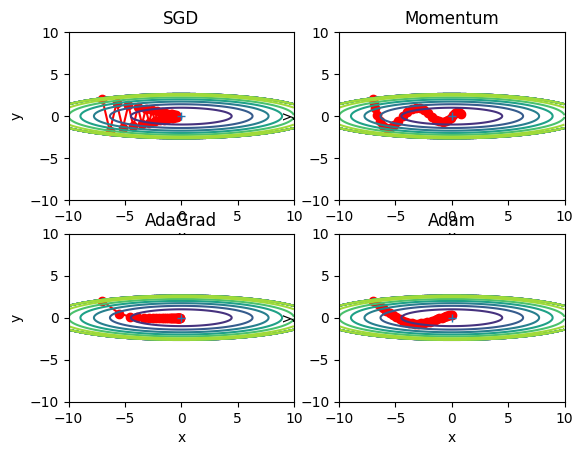

In [2]:
def f(x, y):
    return x**2 / 20.0 + y**2


def df(x, y):
    return x / 10.0, 2.0*y

init_pos = (-7.0, 2.0)
params = {}
params['x'], params['y'] = init_pos[0], init_pos[1]
grads = {}
grads['x'], grads['y'] = 0, 0


optimizers = OrderedDict()
optimizers["SGD"] = SGD(lr=0.95)
optimizers["Momentum"] = Momentum(lr=0.1)
optimizers["AdaGrad"] = AdaGrad(lr=1.5)
optimizers["Adam"] = Adam(lr=0.3)

idx = 1

for key in optimizers:
    optimizer = optimizers[key]
    x_history = []
    y_history = []
    params['x'], params['y'] = init_pos[0], init_pos[1]
    
    for i in range(30):
        x_history.append(params['x'])
        y_history.append(params['y'])
        
        grads['x'], grads['y'] = df(params['x'], params['y'])
        optimizer.update(params, grads)
    

    x = np.arange(-10, 10, 0.01)
    y = np.arange(-5, 5, 0.01)
    
    X, Y = np.meshgrid(x, y) 
    Z = f(X, Y)
    
    # 외곽선 단순화
    mask = Z > 7
    Z[mask] = 0
    
    # 그래프 그리기
    plt.subplot(2, 2, idx)
    idx += 1
    plt.plot(x_history, y_history, 'o-', color="red")
    plt.contour(X, Y, Z)
    plt.ylim(-10, 10)
    plt.xlim(-10, 10)
    plt.plot(0, 0, '+')
    #colorbar()
    #spring()
    plt.title(key)
    plt.xlabel("x")
    plt.ylabel("y")
    
plt.show()

In [43]:
import mnist as mnist
from common.util import smooth_curve
from common.multi_layer_net import MultiLayerNet
from common.optimizer import *

### mnist 데이터에 옵티마이저 성능 비교   

===========iteration:0===========
SGD:2.3535681463706055
Momentum:2.3463688927839863
AdaGrad:2.4218935518053777
Adam:2.196425095620849
===========iteration:100===========
SGD:1.5566790408948967
Momentum:0.29742121201242255
AdaGrad:0.12164442971767786
Adam:0.27861377292402234
===========iteration:200===========
SGD:0.6794483091168729
Momentum:0.23618372195787096
AdaGrad:0.09749520983952895
Adam:0.20656875175453474
===========iteration:300===========
SGD:0.40060755020269856
Momentum:0.15602106811167005
AdaGrad:0.037879751299588454
Adam:0.10243770017507824
===========iteration:400===========
SGD:0.33933140442845866
Momentum:0.1443660298926785
AdaGrad:0.04936547081689362
Adam:0.13863926091042963
===========iteration:500===========
SGD:0.2959703559727622
Momentum:0.11854006072564757
AdaGrad:0.05147559431804039
Adam:0.09853611740389714
===========iteration:600===========
SGD:0.24625270328357238
Momentum:0.10544381617211407
AdaGrad:0.05252983868284293
Adam:0.09597035155411494
===========itera

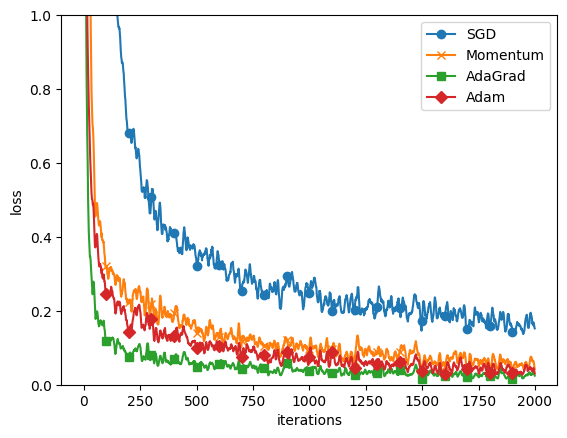

In [5]:
# 0. MNIST 데이터 읽기==========
(x_train, t_train), (x_test, t_test) = mnist.load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1. 실험용 설정==========
optimizers = {}
optimizers['SGD'] = SGD()
optimizers['Momentum'] = Momentum()
optimizers['AdaGrad'] = AdaGrad()
optimizers['Adam'] = Adam()
#optimizers['RMSprop'] = RMSprop()

networks = {}
train_loss = {}
for key in optimizers.keys():
    networks[key] = MultiLayerNet(
        input_size=784, hidden_size_list=[100, 100, 100, 100, 100],
        output_size=10)   # 은닉 층 3개, 출력층 1개인 신경망
    train_loss[key] = []    


# 2. 훈련 시작==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in optimizers.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizers[key].update(networks[key].params, grads)
    
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print( "===========" + "iteration:" + str(i) + "===========")
        for key in optimizers.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3. 그래프 그리기==========
markers = {"SGD": "o", "Momentum": "x", "AdaGrad": "s", "Adam": "D"}
x = np.arange(max_iterations)
for key in optimizers.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 1)
plt.legend()
plt.show()

### 내가 직접 구현해서 옵티마이저 성능 비교   

In [6]:
# 학습률은 모두 동일하게 0.01로 설정하였으나, Adam은 0.001로 설정하였다.

# Sigmoid 계층 생성
class Sigmoid:
  def __init__(self):
      self.out = None
  
  def forward(self, x):
      self.out = 1 / (1 + np.exp(-x))
      return self.out
  
  def backward(self, dout):
      dx = dout * (1 - self.out) * self.out
      return dx
      
# Relu 계층 생성
class Relu:
  def __init__(self):
    self.mask = None
    
  def forward(self, x):
    self.mask = (x <= 0)  # x가 0 이하인 원소는 True, 그 외(0보다 큰 원소)는 False
    out = x.copy()
    out[self.mask] = 0
    return out

  def backward(self, dout):
    dout[self.mask] = 0 # mask의 원소가 True인 곳에는 상류에서 전파된 dout을 0으로 설정
    dx = dout           
    return dx
  
# Affine 계층 생성
class Affine:
  def __init__(self, W, b):
    self.W = W
    self.b = b
    self.x = None
    self.original_x_shape = None
    self.dW = None
    self.db = None
  
  def forward(self, x):
    self.original_x_shape = x.shape
    x = x.reshape(x.shape[0], -1)
    self.x = x
    out = np.dot(self.x, self.W) + self.b
    return out
  
  def backward(self, dout):
    self.dW = np.dot(self.x.T, dout)
    self.db = np.sum(dout, axis=0)
    dx = np.dot(dout, self.W.T)
    dx = dx.reshape(*self.original_x_shape)
    return dx
  
# softmax 함수 생성
def softmax(x):
    if x.ndim == 2:
        x = x.T
        x = x - np.max(x, axis=0)
        y = np.exp(x) / np.sum(np.exp(x), axis=0)
        return y.T 

    x = x - np.max(x) # 오버플로 대책
    return np.exp(x) / np.sum(np.exp(x))
  
# Cross Entropy Error 함수 생성
def cross_entropy_error(y, t):
  if y.ndim == 1:
    t = t.reshape(1, t.size)
    y = y.reshape(1, y.size)
    
# 훈련 데이터가 원-핫 벡터라면 정답 레이블의 인덱스로 반환
  if t.size == y.size:
    t = t.argmax(axis=1)
          
  batch_size = y.shape[0]
  return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size
  
# Softmax with Loss 계층 생성
class SoftmaxWithLoss:
  def __init__(self):
    self.loss = None
    self.y = None
    self.t = None
    
  def forward(self,x,t): # x는 출력값, t는 정답 레이블
    self.t = t
    self.y = softmax(x)
    self.loss = cross_entropy_error(self.y, self.t)
    return self.loss
  
  def backward(self, dout):
    batch_size = self.t.shape[0]
    if self.t.size == self.y.size: # 정답 레이블이 원-핫 인코딩 형태일 때
        dx = (self.y - self.t) / batch_size
    else:
        dx = self.y.copy()
        dx[np.arange(batch_size), self.t] -= 1
        dx = dx / batch_size
    
    return dx
  
# SGD 계층 생성
class SGD:
  def __init__(self, lr=0.01):
    self.lr = lr
    
  def update(self, params, grads): # params는 가중치 리스트, grads는 기울기 리스트
    for key in params.keys():
      params[key] -= self.lr * grads[key]
 
# Momentum 계층 생성     
class Momentum:
  def __init__(self, lr=0.01, momentum=0.9):
      self.lr = lr
      self.momentum = momentum
      self.v = None
      
  def update(self, params, grads):
      if self.v is None:
          self.v = {}
          for key, val in params.items():                                
              self.v[key] = np.zeros_like(val)
              
      for key in params.keys():
          self.v[key] = self.momentum*self.v[key] - self.lr*grads[key] 
          params[key] += self.v[key]
          
# AdaGrad 계층 생성
class AdaGrad:
  def __init__(self, lr=0.01):
      self.lr = lr
      self.h = None
      
  def update(self, params, grads):
      if self.h is None: # 최초 실행 시 h를 0으로 초기화
          self.h = {}
          for key, val in params.items():
              self.h[key] = np.zeros_like(val)
          
      for key in params.keys():
          self.h[key] += grads[key] * grads[key]                              # 기울기의 제곱을 누적 
          params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7) # 각 가중치 매개변수 별로 학습률을 조정시킨다. 
          
# RMSprop 계층 생성
class RMSprop:
  def __init__(self, lr=0.01, decay_rate = 0.99):
      self.lr = lr
      self.decay_rate = decay_rate
      self.h = None
      
  def update(self, params, grads):
      if self.h is None:
          self.h = {}
          for key, val in params.items():
              self.h[key] = np.zeros_like(val)
          
      for key in params.keys():
          self.h[key] *= self.decay_rate                                   # self.decay_rate*self.h[key]
          self.h[key] += (1 - self.decay_rate) * grads[key] * grads[key]   # AdaGrad에서 (1-self.decay_rate)를 곱해주면 된다.
          params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7) # AdaGrad와 마찬가지로 각 가중치 매개변수 별로 학습률을 조정시킨다.
          
# Adam 계층 생성
class Adam:
  def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
      self.lr = lr
      self.beta1 = beta1
      self.beta2 = beta2
      self.t = 0
      self.m = None
      self.v = None
      
  def update(self, params, grads):
      if self.m is None:
          self.m = {}
          self.v = {}
          for key, val in params.items():
              self.m[key] = np.zeros_like(val)
              self.v[key] = np.zeros_like(val)
              
      self.t += 1
      for key in params.keys():
          self.m[key] += (1 - self.beta1) * (grads[key] - self.m[key]) # 기울기의 지수 이동 평균을 계산한다.
          self.v[key] += (1 - self.beta2) * (grads[key] * grads[key] - self.v[key]) # 기울기의 제곱의 지수 이동 평균을 계산한다.
          
          m_hat = self.m[key] / (1 - self.beta1 ** self.t) # 편향 보정
          v_hat = self.v[key] / (1 - self.beta2 ** self.t) # 편향 보정
          
          params[key] -= self.lr * m_hat / (np.sqrt(v_hat) + 1e-7) # 각 가중치 매개변수 별로 학습률을 조정시킨다.

In [44]:
class MultiLayerNet:
    """완전연결 다층 신경망

    Parameters
    ----------
    input_size : 입력 크기（MNIST의 경우엔 784）
    hidden_size_list : 각 은닉층의 뉴런 수를 담은 리스트（e.g. [100, 100, 100]）
    output_size : 출력 크기（MNIST의 경우엔 10）
    activation : 활성화 함수 - 'relu' 혹은 'sigmoid'
    weight_init_std : 가중치의 표준편차 지정（e.g. 0.01）
        'relu'나 'he'로 지정하면 'He 초깃값'으로 설정
        'sigmoid'나 'xavier'로 지정하면 'Xavier 초깃값'으로 설정
    weight_decay_lambda : 가중치 감소(L2 법칙)의 세기
    """
    def __init__(self, input_size, hidden_size_list, output_size,
                 activation='relu', weight_init_std='relu', weight_decay_lambda=0):
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_size_list = hidden_size_list
        self.hidden_layer_num = len(hidden_size_list)
        self.weight_decay_lambda = weight_decay_lambda
        self.params = {}

        # 가중치 초기화
        self.__init_weight(weight_init_std)

        # 계층 생성
        activation_layer = {'sigmoid': Sigmoid, 'relu': Relu}
        self.layers = OrderedDict()
        for idx in range(1, self.hidden_layer_num+1):
            self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)],
                                                      self.params['b' + str(idx)])
            self.layers['Activation_function' + str(idx)] = activation_layer[activation]()

        idx = self.hidden_layer_num + 1
        self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)],
            self.params['b' + str(idx)])

        self.last_layer = SoftmaxWithLoss()

    def __init_weight(self, weight_init_std):
        """가중치 초기화
        
        Parameters
        ----------
        weight_init_std : 가중치의 표준편차 지정（e.g. 0.01）
            'relu'나 'he'로 지정하면 'He 초깃값'으로 설정
            'sigmoid'나 'xavier'로 지정하면 'Xavier 초깃값'으로 설정
        """
        all_size_list = [self.input_size] + self.hidden_size_list + [self.output_size]
        for idx in range(1, len(all_size_list)):
            scale = weight_init_std
            if str(weight_init_std).lower() in ('relu', 'he'):
                scale = np.sqrt(2.0 / all_size_list[idx - 1])  # ReLU를 사용할 때의 권장 초깃값
            elif str(weight_init_std).lower() in ('sigmoid', 'xavier'):
                scale = np.sqrt(1.0 / all_size_list[idx - 1])  # sigmoid를 사용할 때의 권장 초깃값
            self.params['W' + str(idx)] = scale * np.random.randn(all_size_list[idx-1], all_size_list[idx])
            self.params['b' + str(idx)] = np.zeros(all_size_list[idx])

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x

    def loss(self, x, t):
        """손실 함수를 구한다.
        
        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블 
        
        Returns
        -------
        손실 함수의 값
        """
        y = self.predict(x)

        weight_decay = 0
        for idx in range(1, self.hidden_layer_num + 2):
            W = self.params['W' + str(idx)]
            weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W ** 2)

        return self.last_layer.forward(y, t) + weight_decay

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        if t.ndim != 1 : t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    # def numerical_gradient(self, x, t):
    #     """기울기를 구한다(수치 미분).
        
    #     Parameters
    #     ----------
    #     x : 입력 데이터
    #     t : 정답 레이블
        
    #     Returns
    #     -------
    #     각 층의 기울기를 담은 딕셔너리(dictionary) 변수
    #         grads['W1']、grads['W2']、... 각 층의 가중치
    #         grads['b1']、grads['b2']、... 각 층의 편향
    #     """
    #     loss_W = lambda W: self.loss(x, t)

    #     grads = {}
    #     for idx in range(1, self.hidden_layer_num+2):
    #         grads['W' + str(idx)] = numerical_gradient(loss_W, self.params['W' + str(idx)])
    #         grads['b' + str(idx)] = numerical_gradient(loss_W, self.params['b' + str(idx)])

    #     return grads

    def gradient(self, x, t):
        """기울기를 구한다(오차역전파법).

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블
        
        Returns
        -------
        각 층의 기울기를 담은 딕셔너리(dictionary) 변수
            grads['W1']、grads['W2']、... 각 층의 가중치
            grads['b1']、grads['b2']、... 각 층의 편향
        """
        # forward
        self.loss(x, t)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 결과 저장
        grads = {}
        for idx in range(1, self.hidden_layer_num+2):
            grads['W' + str(idx)] = self.layers['Affine' + str(idx)].dW + self.weight_decay_lambda * self.layers['Affine' + str(idx)].W
            grads['b' + str(idx)] = self.layers['Affine' + str(idx)].db

        return grads

===========iteration:0===========
SGD:2.375108013788916
Momentum:2.5016037684688133
AdaGrad:2.2108506647338366
Adam:2.199399983390539
RMSprop:14.22925630514289
===========iteration:100===========
SGD:1.5517139172824543
Momentum:0.2613554429258961
AdaGrad:0.12211901933888153
Adam:0.16886563263963533
RMSprop:0.4067159881056608
===========iteration:200===========
SGD:0.7680786789531047
Momentum:0.22986073053929443
AdaGrad:0.11397001820727283
Adam:0.1820803098372747
RMSprop:0.2036014075019728
===========iteration:300===========
SGD:0.4909523895576873
Momentum:0.17705942012684367
AdaGrad:0.0962944796641509
Adam:0.15825942632406884
RMSprop:0.2743429814402629
===========iteration:400===========
SGD:0.4715122769124691
Momentum:0.1823595980340893
AdaGrad:0.10255018871958124
Adam:0.16946800440903337
RMSprop:0.1625815231473019
===========iteration:500===========
SGD:0.39629626084367403
Momentum:0.08548759557358873
AdaGrad:0.05270653816746105
Adam:0.10398834601178303
RMSprop:0.1798958293154564
===

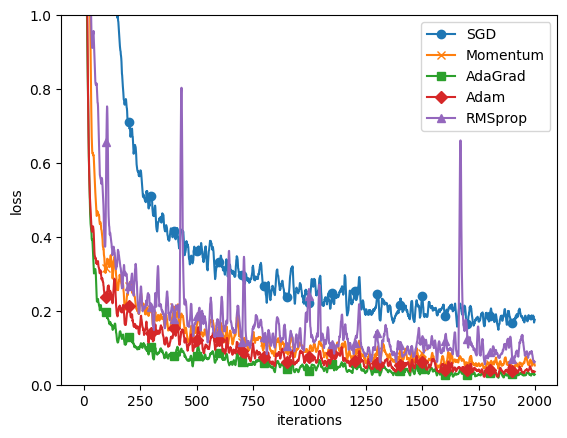

In [ ]:
# 0. MNIST 데이터 읽기==========
(x_train, t_train), (x_test, t_test) = mnist.load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000
# 총 2000회 반복, 한 번 반복할 때 128개의 데이터를 사용


# 1. 실험용 설정==========
optimizers = {}
optimizers['SGD'] = SGD()
optimizers['Momentum'] = Momentum()
optimizers['AdaGrad'] = AdaGrad()
optimizers['Adam'] = Adam()
optimizers['RMSprop'] = RMSprop()

networks = {}
train_loss = {}
for key in optimizers.keys():
    networks[key] = MultiLayerNet(
        input_size=784, hidden_size_list=[100, 100, 100, 100, 100],
        output_size=10)   # 은닉 층 5개, 출력층 1개인 신경망
    train_loss[key] = []    


# 2. 훈련 시작==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in optimizers.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizers[key].update(networks[key].params, grads)
    
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print( "===========" + "iteration:" + str(i) + "===========")
        for key in optimizers.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3. 그래프 그리기==========
markers = {"SGD": "o", "Momentum": "x", "AdaGrad": "s", "Adam": "D", "RMSprop": "^"}
x = np.arange(max_iterations)
for key in optimizers.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 1)
plt.legend()
plt.show()

RSMProp은 모멘텀보다 최적점으로 도달하는데 시간이 더 오래걸린다. 이유: 모멘텀은 관성이    
또한 RMSProp의 loss가 크게 튀는 경우가 발생했는데 이는 RSMProp이 현재 time step의 기울기에 큰 영향을 받기 때문이다. 현재 time step에서 새로 누적된 기울기가 작다 보니 그 방향으로 이동을 했는데 그 곳이 loss가 최소화되는 방향이 아니었기 때문에 loss가 커진 것이다.    
SGD의 경우에는 가중치 매개변수의 기울기를 학습률에 곱해서 가중치를 조정해나가기 때문에 만약 기울기가 0으로 수렴하게 되면 더 이상 나아가지 못하고 최적점에 도달하지 못한채 학습이 끝나게 된다. 그러므로 다른 옵티마이저와 비교했을 때 가장 loss 값이 높은 것을 알 수 있었다.   
Momentum의 경우는 loss 값이 초반에 줄지 않을 수도 있었지만 이전의 기울기 크기를 고려해 가중치 매개변수의 업데이트를 이끌어내어 추가적으로 loss를 줄여나갈 수 있었다.    
Adagrad의 경우는 다른 옵티마이저보다 가장 빠르게 loss가 감소하였으나 최적점으로 도달하기까지 시간이 오래걸렸다. 그 이유는 Adagrad는 과거의 기울기를 제곱한 값을 학습률을 조정하는데 사용하는데 제곱한 값이 학습이 진행됨에 따라 점차 0으로 수렴하게 되어 학습률도 감소해 학습 진행이 느려졌기 때문이다.   
Adam의 경우는 RMSProp과 Momentum의 장점을 모두 활용해서 가중치 매개변수 갱신의 학습률을 조정해 나가기 때문에 두 옵티마이저보다 최적점으로 도달하는데 더 빠른 것을 알 수 있었다.   


### mnist 데이터를 활용하여 가중치 초기화 기법 비교   

===========iteration:0===========
std=0.01:2.3023648395782024
Xavier:2.2723104661293085
He:2.197351992209579
===========iteration:100===========
std=0.01:2.2369432394454463
Xavier:0.44100104764998516
He:0.2777639754143473
===========iteration:200===========
std=0.01:1.1671337223967857
Xavier:0.35579914387483813
He:0.23814740728534728
===========iteration:300===========
std=0.01:0.7367396679163556
Xavier:0.2244905512619171
He:0.11665088552036296
===========iteration:400===========
std=0.01:0.4518916402225145
Xavier:0.16058239246661835
He:0.14091869862995088
===========iteration:500===========
std=0.01:0.5955462494427728
Xavier:0.3164024283092447
He:0.20061695473178565
===========iteration:600===========
std=0.01:0.2912749787213166
Xavier:0.14893085361703334
He:0.14154216543108733
===========iteration:700===========
std=0.01:0.257359361316774
Xavier:0.10825613921444549
He:0.08763398422338356
===========iteration:800===========
std=0.01:0.20406348746100164
Xavier:0.10287253195583193
He:0.

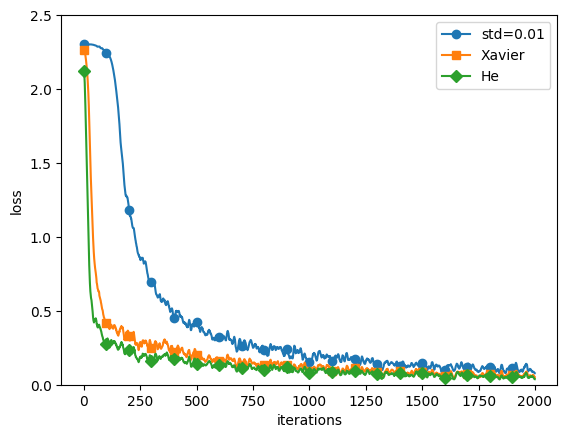

In [12]:
from common.optimizer import SGD


# 0. MNIST 데이터 읽기==========
(x_train, t_train), (x_test, t_test) = mnist.load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1. 실험용 설정==========
weight_init_types = {'std=0.01': 0.01, 'Xavier': 'sigmoid', 'He': 'relu'} # 가중치 초기화 방법, 표준편차 0.01로 설정, Xavier(활성화 함수가 시그모이드인 경우), He(활성화 함수가 ReLU인 경우)
optimizer = Adam(lr=0.001)

networks = {}
train_loss = {}
for key, weight_type in weight_init_types.items():
    networks[key] = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100],
                                  output_size=10, weight_init_std=weight_type)
    train_loss[key] = []


# 2. 훈련 시작==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in weight_init_types.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizer.update(networks[key].params, grads)
    
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print("===========" + "iteration:" + str(i) + "===========")
        for key in weight_init_types.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3. 그래프 그리기==========
markers = {'std=0.01': 'o', 'Xavier': 's', 'He': 'D'}
x = np.arange(max_iterations)
for key in weight_init_types.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 2.5)
plt.legend()
plt.show()

### 내가 직접 구현해서 가중치 초기화 방법 비교  

In [45]:
class Tanh:
  def __init__(self):
      self.out = None

  def forward(self, x):
      self.out = np.tanh(x)
      return self.out

  def backward(self, dout):
      dx = dout * (1.0 - self.out ** 2)
      return dx

In [50]:
class MultiLayerNet:
    """완전연결 다층 신경망

    Parameters
    ----------
    input_size : 입력 크기（MNIST의 경우엔 784）
    hidden_size_list : 각 은닉층의 뉴런 수를 담은 리스트（e.g. [100, 100, 100]）
    output_size : 출력 크기（MNIST의 경우엔 10）
    activation : 활성화 함수 - 'relu' 혹은 'sigmoid'
    weight_init_std : 가중치의 표준편차 지정（e.g. 0.01）
        'relu'나 'he'로 지정하면 'He 초깃값'으로 설정
        'sigmoid'나 'xavier'로 지정하면 'Xavier 초깃값'으로 설정
    weight_decay_lambda : 가중치 감소(L2 법칙)의 세기
    """
    def __init__(self, input_size, hidden_size_list, output_size,
                 activation='relu', weight_init_std='relu', weight_decay_lambda=0):
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_size_list = hidden_size_list
        self.hidden_layer_num = len(hidden_size_list)
        self.weight_decay_lambda = weight_decay_lambda
        self.params = {}

        # 가중치 초기화
        self.__init_weight(weight_init_std)

        # 계층 생성
        activation_layer = {'sigmoid': Sigmoid, 'relu': Relu, 'tanh': Tanh}
        self.layers = OrderedDict()
        for idx in range(1, self.hidden_layer_num+1):
            self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)],
                                                      self.params['b' + str(idx)])
            self.layers['Activation_function' + str(idx)] = activation_layer[activation]()

        idx = self.hidden_layer_num + 1
        self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)],
            self.params['b' + str(idx)])

        self.last_layer = SoftmaxWithLoss()

    def __init_weight(self, weight_init_std):
        """가중치 초기화
        
        Parameters
        ----------
        weight_init_std : 가중치의 표준편차 지정（e.g. 0.01）
            'relu'나 'he'로 지정하면 'He 초깃값'으로 설정
            'sigmoid'나 'xavier'로 지정하면 'Xavier 초깃값'으로 설정
        """
        all_size_list = [self.input_size] + self.hidden_size_list + [self.output_size]
        for idx in range(1, len(all_size_list)):
            scale = weight_init_std
            if str(weight_init_std).lower() in ('relu', 'he'):
                scale = np.sqrt(2.0 / all_size_list[idx - 1])  # ReLU를 사용할 때의 권장 초깃값
            elif str(weight_init_std).lower() in ('sigmoid', 'xavier'):
                scale = np.sqrt(1.0 / all_size_list[idx - 1])  # sigmoid를 사용할 때의 권장 초깃값    
            elif str(weight_init_std).lower() in ('lecun'):
                scale = np.sqrt(1.0 / all_size_list[idx - 1])  # LeCun 초깃값
            elif str(weight_init_std).lower() in ('tanh','xavier(tanh)'):
                scale = np.sqrt(1.0 / all_size_list[idx - 1])  # tanh를 사용할 때의 권장 초깃값
            self.params['W' + str(idx)] = scale * np.random.randn(all_size_list[idx-1], all_size_list[idx])
            self.params['b' + str(idx)] = np.zeros(all_size_list[idx])

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x

    def loss(self, x, t):
        """손실 함수를 구한다.
        
        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블 
        
        Returns
        -------
        손실 함수의 값
        """
        y = self.predict(x)

        weight_decay = 0
        for idx in range(1, self.hidden_layer_num + 2):
            W = self.params['W' + str(idx)]
            weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W ** 2)

        return self.last_layer.forward(y, t) + weight_decay

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        if t.ndim != 1 : t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    # def numerical_gradient(self, x, t):
    #     """기울기를 구한다(수치 미분).
        
    #     Parameters
    #     ----------
    #     x : 입력 데이터
    #     t : 정답 레이블
        
    #     Returns
    #     -------
    #     각 층의 기울기를 담은 딕셔너리(dictionary) 변수
    #         grads['W1']、grads['W2']、... 각 층의 가중치
    #         grads['b1']、grads['b2']、... 각 층의 편향
    #     """
    #     loss_W = lambda W: self.loss(x, t)

    #     grads = {}
    #     for idx in range(1, self.hidden_layer_num+2):
    #         grads['W' + str(idx)] = numerical_gradient(loss_W, self.params['W' + str(idx)])
    #         grads['b' + str(idx)] = numerical_gradient(loss_W, self.params['b' + str(idx)])

    #     return grads

    def gradient(self, x, t):
        """기울기를 구한다(오차역전파법).

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블
        
        Returns
        -------
        각 층의 기울기를 담은 딕셔너리(dictionary) 변수
            grads['W1']、grads['W2']、... 각 층의 가중치
            grads['b1']、grads['b2']、... 각 층의 편향
        """
        # forward
        self.loss(x, t)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 결과 저장
        grads = {}
        for idx in range(1, self.hidden_layer_num+2):
            grads['W' + str(idx)] = self.layers['Affine' + str(idx)].dW + self.weight_decay_lambda * self.layers['Affine' + str(idx)].W
            grads['b' + str(idx)] = self.layers['Affine' + str(idx)].db

        return grads

===========iteration:0===========
std=0.01:2.302325352871515
Xavier:2.2718140122887442
He:2.210769140544376
lecun:2.290523004552176
Xavier(tanh):2.2985611002283344
===========iteration:100===========
std=0.01:2.2697229892859907
Xavier:0.5816157751272861
He:0.3514942692662031
lecun:0.6474545099646771
Xavier(tanh):0.5190951041053004
===========iteration:200===========
std=0.01:1.8875042431888311
Xavier:0.2989357954464895
He:0.19228170349302753
lecun:0.2980460895715443
Xavier(tanh):0.25577090800013436
===========iteration:300===========
std=0.01:0.9848699134700099
Xavier:0.33110411106957327
He:0.22918029755874403
lecun:0.3042002682893341
Xavier(tanh):0.28145990636419294
===========iteration:400===========
std=0.01:0.680016630302674
Xavier:0.45193809157475506
He:0.2811293575367262
lecun:0.3561147833565926
Xavier(tanh):0.37594790007115253
===========iteration:500===========
std=0.01:0.4799083055455212
Xavier:0.18079352654768838
He:0.1461240066200818
lecun:0.17444354717777405
Xavier(tanh):0.

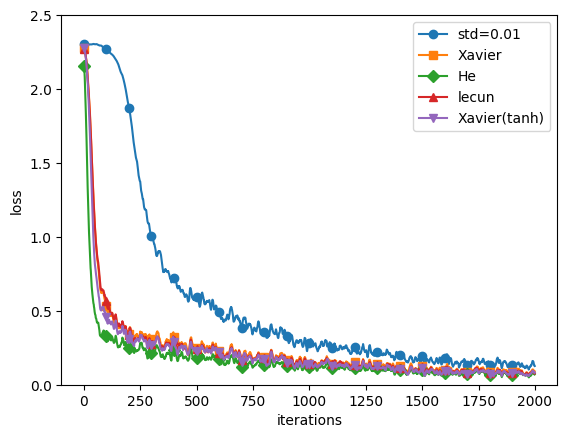

In [51]:
# 0. MNIST 데이터 읽기==========
(x_train, t_train), (x_test, t_test) = mnist.load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1. 실험용 설정==========
weight_init_types = {'std=0.01': 0.01, 'Xavier': 'sigmoid', 'He': 'relu', 'lecun':'sigmoid', 'Xavier(tanh)':'tanh'} # 가중치 초기화 방법, 표준편차 0.01로 설정, Xavier(활성화 함수가 시그모이드인 경우), He(활성화 함수가 ReLU인 경우)
optimizer = Adam(lr=0.001)

networks = {}
train_loss = {}
for key, weight_type in weight_init_types.items():
    networks[key] = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100],
                                  output_size=10, weight_init_std=weight_type)
    train_loss[key] = []


# 2. 훈련 시작==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in weight_init_types.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizer.update(networks[key].params, grads)
    
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print("===========" + "iteration:" + str(i) + "===========")
        for key in weight_init_types.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3. 그래프 그리기==========
markers = {'std=0.01': 'o', 'Xavier': 's', 'He': 'D', 'lecun': '^', 'Xavier(tanh)': 'v'}
x = np.arange(max_iterations)
for key in weight_init_types.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 2.5)
plt.legend()
plt.show()

가중치 초기화 설정에 따른 모델 학습 성능을 비교해보았다. 평균을 0, 표준편차를 0.01로 가중치를 랜덤하게 초기화하는 방법을 제외하고 전부 학습이 잘 된 것을 볼 수 있다. 추가적으로 lecun 

### 배치 정규화 -> 각 층에서의 활성화 값을 적당히 분포시키는 방법   

In [27]:
from common.multi_layer_net_extend import MultiLayerNetExtend 

============== 1/16 ==============
epoch:0 | 0.087 - 0.092
epoch:1 | 0.097 - 0.302
epoch:2 | 0.097 - 0.449
epoch:3 | 0.097 - 0.554
epoch:4 | 0.097 - 0.636
epoch:5 | 0.097 - 0.694
epoch:6 | 0.097 - 0.733
epoch:7 | 0.097 - 0.779
epoch:8 | 0.097 - 0.812
epoch:9 | 0.097 - 0.825
============== 2/16 ==============
epoch:0 | 0.094 - 0.105


C:\Users\KimDongyoung\AppData\Local\Temp\ipykernel_24028\3362466189.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


epoch:1 | 0.097 - 0.36
epoch:2 | 0.097 - 0.553
epoch:3 | 0.097 - 0.671
epoch:4 | 0.097 - 0.746
epoch:5 | 0.097 - 0.814
epoch:6 | 0.097 - 0.861
epoch:7 | 0.097 - 0.897
epoch:8 | 0.097 - 0.923
epoch:9 | 0.097 - 0.944
============== 3/16 ==============
epoch:0 | 0.15 - 0.079
epoch:1 | 0.963 - 0.515
epoch:2 | 1.0 - 0.752
epoch:3 | 1.0 - 0.849
epoch:4 | 1.0 - 0.899
epoch:5 | 1.0 - 0.936
epoch:6 | 1.0 - 0.956
epoch:7 | 1.0 - 0.969
epoch:8 | 1.0 - 0.977
epoch:9 | 1.0 - 0.983
============== 4/16 ==============
epoch:0 | 0.089 - 0.108
epoch:1 | 0.845 - 0.701
epoch:2 | 0.914 - 0.849
epoch:3 | 0.956 - 0.918
epoch:4 | 0.982 - 0.951
epoch:5 | 0.996 - 0.97
epoch:6 | 0.997 - 0.985
epoch:7 | 0.999 - 0.993
epoch:8 | 0.999 - 0.995
epoch:9 | 0.999 - 0.998
============== 5/16 ==============
epoch:0 | 0.13 - 0.111
epoch:1 | 0.184 - 0.814
epoch:2 | 0.378 - 0.931
epoch:3 | 0.426 - 0.969
epoch:4 | 0.603 - 0.983
epoch:5 | 0.75 - 0.995
epoch:6 | 0.81 - 0.998
epoch:7 | 0.849 - 0.999
epoch:8 | 0.882 - 1.0
epoch:9

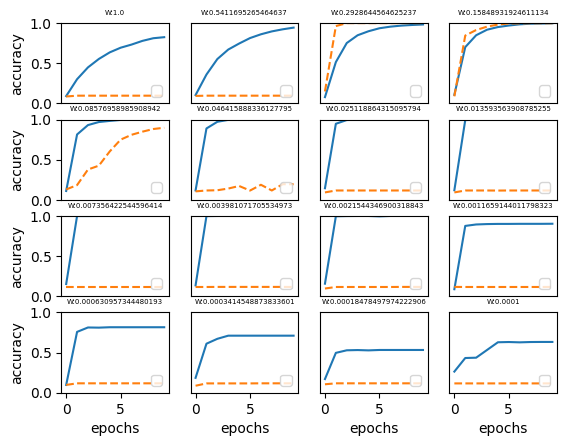

In [58]:
(x_train, t_train), (x_test, t_test) =mnist.load_mnist(normalize=True)

# 학습 데이터를 줄임
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 10
train_size = x_train.shape[0]
batch_size = 128
learning_rate = 0.01


def __train(weight_init_std):
    # bn_network는 배치 정규화를 사용한 신경망, network는 배치 정규화를 사용하지 않은 신경망
    # 5개의 은닉층을 가진 신경망을 생성한다. -> hidden_size_list를 조정하면 은닉층의 개수를 조정할 수 있다.
    # 각 은닉층 노드는 100개로 설정, 출력층은 10개로 설정 -> 다중 분류 문제이다. 
    bn_network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10, 
                                    weight_init_std=weight_init_std, use_batchnorm=True)
    network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)
    
    train_acc_list = []
    bn_train_acc_list = []
    
    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0
    
    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size) # 100개의 데이터를 무작위로 선택
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]
    
        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)
    
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)
    
            print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - " + str(bn_train_acc))
    
            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break
                
    return train_acc_list, bn_train_acc_list


# 그래프 그리기==========
# 로그 스케일로 균등하게 분포된 숫자 생성
weight_scale_list = np.logspace(0, -4, num=16) # 0.0001 ~ 1.0까지 로그 스케일로 균등하게 분포된 숫자 생성, 16개 생성하고 지수적으로 감소한다. 
x = np.arange(max_epochs)

for i, w in enumerate(weight_scale_list):
    print( "============== " + str(i+1) + "/16" + " ==============")
    train_acc_list, bn_train_acc_list = __train(w)
    
    plt.subplot(4,4,i+1)
    plt.title("W:" + str(w), fontsize=5) # fontsize=5, 폰트 크기 조정
    if i == 15:
        plt.plot(x, bn_train_acc_list, markevery=2)
        plt.plot(x, train_acc_list, linestyle = "--", markevery=2)
    else:
        plt.plot(x, bn_train_acc_list, markevery=2)
        plt.plot(x, train_acc_list, linestyle="--", markevery=2)

    plt.ylim(0, 1.0)
    if i % 4:
        plt.yticks([])
    else:
        plt.ylabel("accuracy")
    if i < 12:
        plt.xticks([])
    else:
        plt.xlabel("epochs")
    plt.legend(loc='lower right')
    
plt.show()

============== 1/16 ==============
epoch:0 | 0.099 - 0.099
epoch:1 | 0.097 - 0.334
epoch:2 | 0.097 - 0.494
epoch:3 | 0.097 - 0.609
epoch:4 | 0.097 - 0.684
epoch:5 | 0.097 - 0.736
epoch:6 | 0.097 - 0.781
epoch:7 | 0.097 - 0.815
epoch:8 | 0.097 - 0.835
epoch:9 | 0.097 - 0.86


C:\Users\KimDongyoung\AppData\Local\Temp\ipykernel_24028\3531244318.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


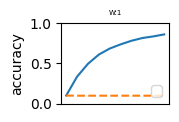

In [ ]:
(x_train, t_train), (x_test, t_test) =mnist.load_mnist(normalize=True)

# 학습 데이터를 줄임
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 10
train_size = x_train.shape[0]
batch_size = 128
learning_rate = 0.01


def __train(weight_init_std):
    # bn_network는 배치 정규화를 사용한 신경망, network는 배치 정규화를 사용하지 않은 신경망
    # 5개의 은닉층을 가진 신경망을 생성한다. -> hidden_size_list를 조정하면 은닉층의 개수를 조정할 수 있다.
    # 각 은닉층 노드는 100개로 설정, 출력층은 10개로 설정 -> 다중 분류 문제이다. 
    bn_network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100,100,100], output_size=10, 
                                    weight_init_std=weight_init_std, use_batchnorm=True)
    network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100,100,100], output_size=10,
                                weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)
    
    train_acc_list = []
    bn_train_acc_list = []
    
    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0
    
    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]
    
        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)
    
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)
    
            print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - " + str(bn_train_acc))
    
            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break
                
    return train_acc_list, bn_train_acc_list


# 그래프 그리기==========
# 로그 스케일로 균등하게 분포된 숫자 생성
# weight_scale_list = np.logspace(0, -4, num=16) # 0.0001 ~ 1.0까지 로그 스케일로 균등하게 분포된 숫자 생성, 16개 생성하고 지수적으로 감소한다.
weight_scale_list = [1] # 0.01로 설정



epoch:0 | 0.117 - 0.076
epoch:1 | 0.097 - 0.275
epoch:2 | 0.097 - 0.446
epoch:3 | 0.097 - 0.553
epoch:4 | 0.097 - 0.636
epoch:5 | 0.097 - 0.69
epoch:6 | 0.097 - 0.728
epoch:7 | 0.097 - 0.756
epoch:8 | 0.097 - 0.79
epoch:9 | 0.097 - 0.821


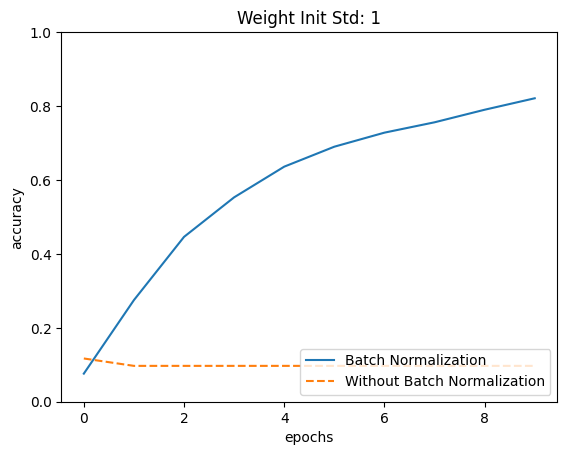

In [76]:
train_acc_list, bn_train_acc_list = __train(weight_scale_list[0])

plt.title("Weight Init Std: " + str(weight_scale_list[0]), fontsize=12)
plt.plot(x, bn_train_acc_list, label='Batch Normalization', markevery=2)
plt.plot(x, train_acc_list, linestyle="--", label='Without Batch Normalization', markevery=2)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

epoch:0 | 0.1 - 0.129
epoch:1 | 0.097 - 0.318
epoch:2 | 0.097 - 0.438
epoch:3 | 0.097 - 0.545
epoch:4 | 0.097 - 0.613
epoch:5 | 0.097 - 0.665
epoch:6 | 0.097 - 0.683
epoch:7 | 0.097 - 0.737
epoch:8 | 0.097 - 0.773
epoch:9 | 0.097 - 0.794


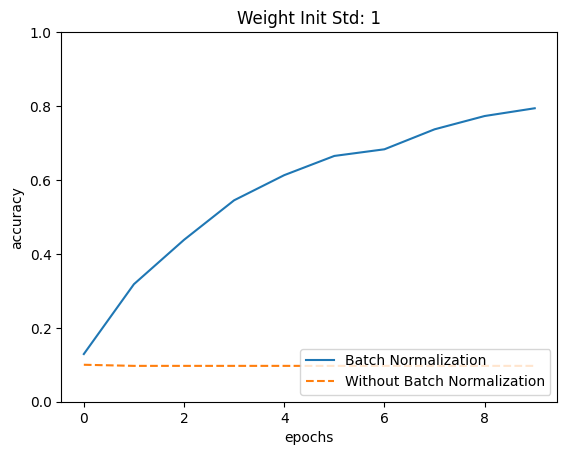

In [77]:
batch_size = 64

train_acc_list, bn_train_acc_list = __train(weight_scale_list[0])

plt.title("Weight Init Std: " + str(weight_scale_list[0]), fontsize=12)
plt.plot(x, bn_train_acc_list, label='Batch Normalization', markevery=2)
plt.plot(x, train_acc_list, linestyle="--", label='Without Batch Normalization', markevery=2)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

epoch:0 | 0.099 - 0.078
epoch:1 | 0.097 - 0.235
epoch:2 | 0.097 - 0.377
epoch:3 | 0.097 - 0.478
epoch:4 | 0.097 - 0.545
epoch:5 | 0.097 - 0.588
epoch:6 | 0.097 - 0.622
epoch:7 | 0.097 - 0.637
epoch:8 | 0.097 - 0.68
epoch:9 | 0.097 - 0.685


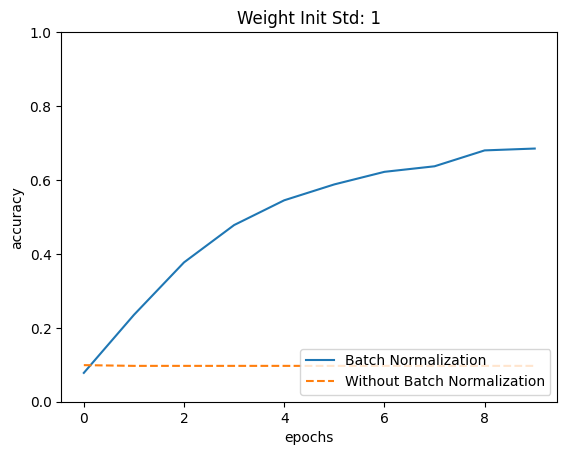

In [78]:
batch_size = 16

train_acc_list, bn_train_acc_list = __train(weight_scale_list[0])

plt.title("Weight Init Std: " + str(weight_scale_list[0]), fontsize=12)
plt.plot(x, bn_train_acc_list, label='Batch Normalization', markevery=2)
plt.plot(x, train_acc_list, linestyle="--", label='Without Batch Normalization', markevery=2)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

### 오버피팅 방지     

### 가중치 감소  

In [83]:
class MultiLayerNet:
    """완전연결 다층 신경망

    Parameters
    ----------
    input_size : 입력 크기（MNIST의 경우엔 784）
    hidden_size_list : 각 은닉층의 뉴런 수를 담은 리스트（e.g. [100, 100, 100]）
    output_size : 출력 크기（MNIST의 경우엔 10）
    activation : 활성화 함수 - 'relu' 혹은 'sigmoid'
    weight_init_std : 가중치의 표준편차 지정（e.g. 0.01）
        'relu'나 'he'로 지정하면 'He 초깃값'으로 설정
        'sigmoid'나 'xavier'로 지정하면 'Xavier 초깃값'으로 설정
    weight_decay_lambda : 가중치 감소(L2 법칙)의 세기
    """
    def __init__(self, input_size, hidden_size_list, output_size,
                 activation='relu', weight_init_std='relu', weight_decay_lambda=0):
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_size_list = hidden_size_list
        self.hidden_layer_num = len(hidden_size_list)
        self.weight_decay_lambda = weight_decay_lambda
        self.params = {}

        # 가중치 초기화
        self.__init_weight(weight_init_std)

        # 계층 생성
        activation_layer = {'sigmoid': Sigmoid, 'relu': Relu}
        self.layers = OrderedDict()
        for idx in range(1, self.hidden_layer_num+1):
            self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)],
                                                      self.params['b' + str(idx)])
            self.layers['Activation_function' + str(idx)] = activation_layer[activation]()

        idx = self.hidden_layer_num + 1
        self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)],
            self.params['b' + str(idx)])

        self.last_layer = SoftmaxWithLoss()

    def __init_weight(self, weight_init_std):
        """가중치 초기화
        
        Parameters
        ----------
        weight_init_std : 가중치의 표준편차 지정（e.g. 0.01）
            'relu'나 'he'로 지정하면 'He 초깃값'으로 설정
            'sigmoid'나 'xavier'로 지정하면 'Xavier 초깃값'으로 설정
        """
        all_size_list = [self.input_size] + self.hidden_size_list + [self.output_size]
        for idx in range(1, len(all_size_list)):
            scale = weight_init_std
            if str(weight_init_std).lower() in ('relu', 'he'):
                scale = np.sqrt(2.0 / all_size_list[idx - 1])  # ReLU를 사용할 때의 권장 초깃값
            elif str(weight_init_std).lower() in ('sigmoid', 'xavier'):
                scale = np.sqrt(1.0 / all_size_list[idx - 1])  # sigmoid를 사용할 때의 권장 초깃값
            self.params['W' + str(idx)] = scale * np.random.randn(all_size_list[idx-1], all_size_list[idx])
            self.params['b' + str(idx)] = np.zeros(all_size_list[idx])

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x

    def loss(self, x, t):
        """손실 함수를 구한다.
        
        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블 
        
        Returns
        -------
        손실 함수의 값
        """
        y = self.predict(x)

        weight_decay = 0
        for idx in range(1, self.hidden_layer_num + 2):
            W = self.params['W' + str(idx)]
            # weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W ** 2) # 가중치 감소 방법으로 L2 법칙을 사용
            weight_decay += self.weight_decay_lambda * np.sum(np.abs(W))      # 가중치 감소 방법으로 L1 법칙을 사용

        return self.last_layer.forward(y, t) + weight_decay

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        if t.ndim != 1 : t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    # def numerical_gradient(self, x, t):
    #     """기울기를 구한다(수치 미분).
        
    #     Parameters
    #     ----------
    #     x : 입력 데이터
    #     t : 정답 레이블
        
    #     Returns
    #     -------
    #     각 층의 기울기를 담은 딕셔너리(dictionary) 변수
    #         grads['W1']、grads['W2']、... 각 층의 가중치
    #         grads['b1']、grads['b2']、... 각 층의 편향
    #     """
    #     loss_W = lambda W: self.loss(x, t)

    #     grads = {}
    #     for idx in range(1, self.hidden_layer_num+2):
    #         grads['W' + str(idx)] = numerical_gradient(loss_W, self.params['W' + str(idx)])
    #         grads['b' + str(idx)] = numerical_gradient(loss_W, self.params['b' + str(idx)])

    #     return grads

    def gradient(self, x, t):
        """기울기를 구한다(오차역전파법).

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블
        
        Returns
        -------
        각 층의 기울기를 담은 딕셔너리(dictionary) 변수
            grads['W1']、grads['W2']、... 각 층의 가중치
            grads['b1']、grads['b2']、... 각 층의 편향
        """
        # forward
        self.loss(x, t)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 결과 저장
        grads = {}
        for idx in range(1, self.hidden_layer_num+2):
            grads['W' + str(idx)] = self.layers['Affine' + str(idx)].dW + self.weight_decay_lambda * self.layers['Affine' + str(idx)].W
            grads['b' + str(idx)] = self.layers['Affine' + str(idx)].db

        return grads


### L2 norm

epoch:0, train acc:0.09333333333333334, test acc:0.0995
epoch:1, train acc:0.1, test acc:0.1022
epoch:2, train acc:0.11333333333333333, test acc:0.1091
epoch:3, train acc:0.12333333333333334, test acc:0.1208
epoch:4, train acc:0.15666666666666668, test acc:0.1419
epoch:5, train acc:0.19666666666666666, test acc:0.1737
epoch:6, train acc:0.23666666666666666, test acc:0.2093
epoch:7, train acc:0.31, test acc:0.2394
epoch:8, train acc:0.35, test acc:0.2722
epoch:9, train acc:0.3933333333333333, test acc:0.3031
epoch:10, train acc:0.4166666666666667, test acc:0.3189
epoch:11, train acc:0.46, test acc:0.3354
epoch:12, train acc:0.48, test acc:0.3473
epoch:13, train acc:0.49666666666666665, test acc:0.3611
epoch:14, train acc:0.49666666666666665, test acc:0.3706
epoch:15, train acc:0.53, test acc:0.3848
epoch:16, train acc:0.5133333333333333, test acc:0.3917
epoch:17, train acc:0.5133333333333333, test acc:0.3933
epoch:18, train acc:0.52, test acc:0.3985
epoch:19, train acc:0.543333333333333

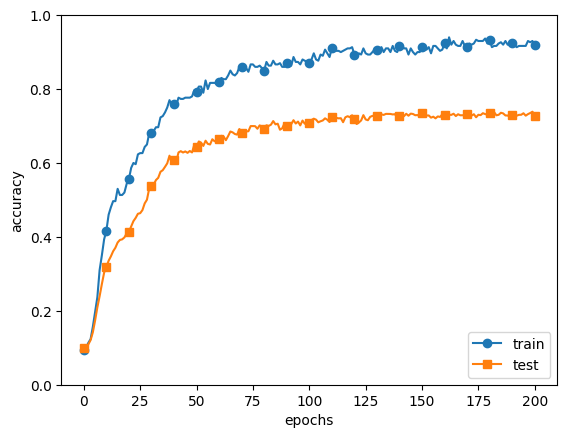

In [38]:
# 가중치 감소, Weight Decay

(x_train, t_train), (x_test, t_test) = mnist.load_mnist(normalize=True)

# 오버피팅을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

# weight decay（가중치 감쇠） 설정 =======================
#weight_decay_lambda = 0 # weight decay를 사용하지 않을 경우
weight_decay_lambda = 0.1 # lambda값을 0.1로 설정
# ====================================================

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01) # 학습률이 0.01인 SGD로 매개변수 갱신

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 그래프 그리기==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

### L2 norm, 에폭: 100    

epoch:0, train acc:0.09666666666666666, test acc:0.0851
epoch:1, train acc:0.12, test acc:0.0945
epoch:2, train acc:0.12333333333333334, test acc:0.1019
epoch:3, train acc:0.15, test acc:0.1125
epoch:4, train acc:0.17333333333333334, test acc:0.1203
epoch:5, train acc:0.21666666666666667, test acc:0.1413
epoch:6, train acc:0.25333333333333335, test acc:0.1594
epoch:7, train acc:0.27666666666666667, test acc:0.1822
epoch:8, train acc:0.2966666666666667, test acc:0.1953
epoch:9, train acc:0.31, test acc:0.213
epoch:10, train acc:0.32666666666666666, test acc:0.2261
epoch:11, train acc:0.32, test acc:0.2361
epoch:12, train acc:0.35333333333333333, test acc:0.2501
epoch:13, train acc:0.36333333333333334, test acc:0.2579
epoch:14, train acc:0.37, test acc:0.26
epoch:15, train acc:0.38666666666666666, test acc:0.2737
epoch:16, train acc:0.39666666666666667, test acc:0.2886
epoch:17, train acc:0.41333333333333333, test acc:0.2951
epoch:18, train acc:0.4166666666666667, test acc:0.3034
epoch:1

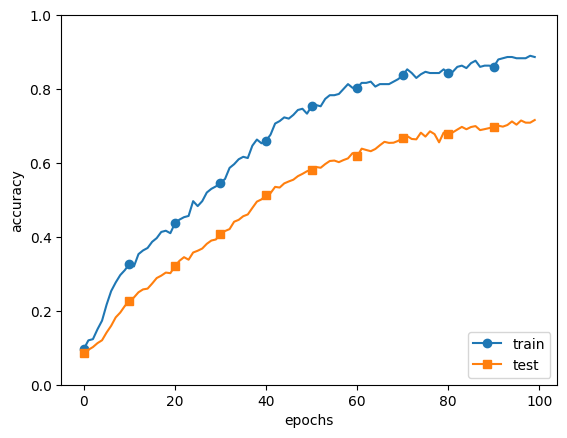

In [82]:
# 가중치 감소, Weight Decay

(x_train, t_train), (x_test, t_test) = mnist.load_mnist(normalize=True)

# 오버피팅을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

# weight decay（가중치 감쇠） 설정 =======================
#weight_decay_lambda = 0 # weight decay를 사용하지 않을 경우
weight_decay_lambda = 0.1 # lambda값을 0.1로 설정
# ====================================================

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01) # 학습률이 0.01인 SGD로 매개변수 갱신

max_epochs = 100
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 그래프 그리기==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

### L1 norm

epoch:0, train acc:0.06666666666666667, test acc:0.0982
epoch:1, train acc:0.10333333333333333, test acc:0.1129
epoch:2, train acc:0.13333333333333333, test acc:0.1315
epoch:3, train acc:0.17666666666666667, test acc:0.1591
epoch:4, train acc:0.21, test acc:0.1843
epoch:5, train acc:0.23333333333333334, test acc:0.1993
epoch:6, train acc:0.25333333333333335, test acc:0.215
epoch:7, train acc:0.2966666666666667, test acc:0.2353
epoch:8, train acc:0.32666666666666666, test acc:0.2505
epoch:9, train acc:0.35333333333333333, test acc:0.2631
epoch:10, train acc:0.37, test acc:0.2774
epoch:11, train acc:0.37666666666666665, test acc:0.2776
epoch:12, train acc:0.3933333333333333, test acc:0.2897
epoch:13, train acc:0.4033333333333333, test acc:0.302
epoch:14, train acc:0.42, test acc:0.3077
epoch:15, train acc:0.41, test acc:0.3071
epoch:16, train acc:0.42, test acc:0.3186
epoch:17, train acc:0.43333333333333335, test acc:0.3276
epoch:18, train acc:0.44, test acc:0.3396
epoch:19, train acc:0.

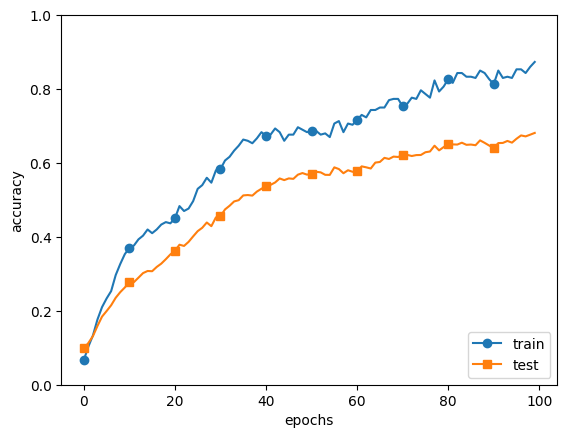

In [84]:
# 가중치 감소, Weight Decay

(x_train, t_train), (x_test, t_test) = mnist.load_mnist(normalize=True)

# 오버피팅을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

# weight decay（가중치 감쇠） 설정 =======================
#weight_decay_lambda = 0 # weight decay를 사용하지 않을 경우
weight_decay_lambda = 0.1 # lambda값을 0.1로 설정
# ====================================================

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01) # 학습률이 0.01인 SGD로 매개변수 갱신

max_epochs = 100    
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 그래프 그리기==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

In [31]:
from common.trainer import Trainer

train loss:2.3482467609254614
=== epoch:1, train acc:0.12, test acc:0.0941 ===
train loss:2.294986121409753
train loss:2.2928452808724873
train loss:2.2919268153380643
=== epoch:2, train acc:0.13, test acc:0.1008 ===
train loss:2.2862210999978427
train loss:2.2963071253815244
train loss:2.2927664722856598
=== epoch:3, train acc:0.13333333333333333, test acc:0.1045 ===
train loss:2.296013048375556
train loss:2.3099309220350035
train loss:2.312885758081906
=== epoch:4, train acc:0.13333333333333333, test acc:0.1074 ===
train loss:2.33139598221754
train loss:2.3033384205544083
train loss:2.320708314278116
=== epoch:5, train acc:0.13666666666666666, test acc:0.1095 ===
train loss:2.279804619188384
train loss:2.319618386903364
train loss:2.281222559420149
=== epoch:6, train acc:0.13666666666666666, test acc:0.1113 ===
train loss:2.2956458978760512
train loss:2.2924941128403806
train loss:2.2745411807136793
=== epoch:7, train acc:0.13666666666666666, test acc:0.1136 ===
train loss:2.27008939

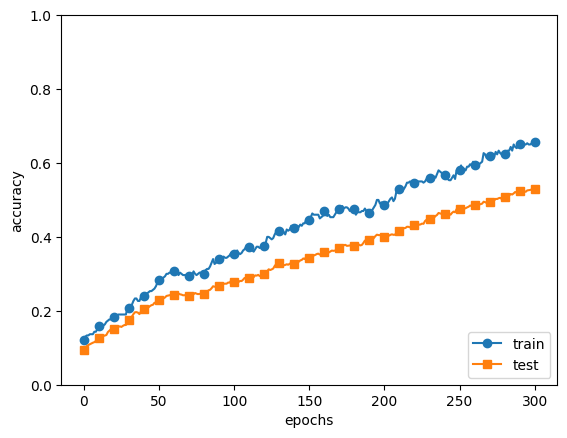

In [32]:
# 드롭아웃, Dropout

(x_train, t_train), (x_test, t_test) = mnist.load_mnist(normalize=True)

# 오버피팅을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

# 드롭아웃 사용 유무와 비울 설정 ========================
use_dropout = True  # 드롭아웃을 쓰지 않을 때는 False
dropout_ratio = 0.2
# ====================================================

# 은닉층이 6개인 신경망을 생성한다. -> hidden_size_list를 조정하면 은닉층의 개수를 조정할 수 있다.
network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                              output_size=10, use_dropout=use_dropout, dropout_ration=dropout_ratio)
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=301, mini_batch_size=100,
                  optimizer='sgd', optimizer_param={'lr': 0.01}, verbose=True)
trainer.train()

train_acc_list, test_acc_list = trainer.train_acc_list, trainer.test_acc_list

# 그래프 그리기==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

train loss:2.346191243484918
=== epoch:1, train acc:0.1, test acc:0.1004 ===
train loss:2.4157170591860018
train loss:2.318820159336954
train loss:2.334809050353051
=== epoch:2, train acc:0.09666666666666666, test acc:0.0994 ===
train loss:2.319092079346402
train loss:2.2587407503080437
train loss:2.273755384399388
=== epoch:3, train acc:0.10333333333333333, test acc:0.1009 ===
train loss:2.29119946582474
train loss:2.2470276050837072
train loss:2.27636973013127
=== epoch:4, train acc:0.11333333333333333, test acc:0.1089 ===
train loss:2.2056621703396395
train loss:2.2074902136328
train loss:2.2684913281569545
=== epoch:5, train acc:0.13, test acc:0.118 ===
train loss:2.1801230044105644
train loss:2.2200922545054436
train loss:2.244360085171634
=== epoch:6, train acc:0.17666666666666667, test acc:0.1336 ===
train loss:2.1832770108465915
train loss:2.1923046562598554
train loss:2.2084499419866677
=== epoch:7, train acc:0.22333333333333333, test acc:0.1446 ===
train loss:2.14367670960334

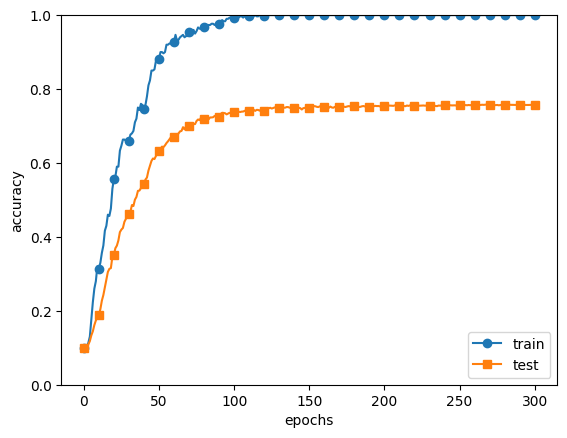

In [15]:
# 드롭아웃 사용 유무와 비울 설정 ========================
use_dropout = False  # 드롭아웃을 쓰지 않을 때는 False
dropout_ratio = 0.2
# ====================================================

# 은닉층이 6개인 신경망을 생성한다. -> hidden_size_list를 조정하면 은닉층의 개수를 조정할 수 있다.
network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                              output_size=10, use_dropout=use_dropout, dropout_ration=dropout_ratio)
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=301, mini_batch_size=100,
                  optimizer='sgd', optimizer_param={'lr': 0.01}, verbose=True)
trainer.train()

train_acc_list, test_acc_list = trainer.train_acc_list, trainer.test_acc_list

# 그래프 그리기==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

### 하이퍼파라미터 최적화 구현  

In [16]:
from common.util import shuffle_dataset

val acc:0.09 | lr:6.574582419200072e-06, weight decay:3.057814655543888e-05
val acc:0.12 | lr:5.31417553145557e-06, weight decay:3.124937684858803e-06
val acc:0.73 | lr:0.0072954813176153484, weight decay:5.516997090280344e-06
val acc:0.06 | lr:1.170348139104676e-06, weight decay:3.893467302074838e-08
val acc:0.32 | lr:0.0015133065905960715, weight decay:7.531237028507283e-05
val acc:0.77 | lr:0.00902677066828107, weight decay:6.918674507640696e-08
val acc:0.08 | lr:5.017054775332703e-06, weight decay:1.2037904653438724e-08
val acc:0.69 | lr:0.006972599493436597, weight decay:6.181342463276302e-07
val acc:0.12 | lr:1.5897295000356635e-06, weight decay:1.3706319486300148e-06
val acc:0.13 | lr:0.0001954480904688054, weight decay:2.4731668540047666e-08
val acc:0.22 | lr:0.0010079072561652099, weight decay:4.5371084407825066e-05
val acc:0.04 | lr:4.3744869573526236e-05, weight decay:1.3973088365390778e-06
val acc:0.19 | lr:2.305821780701876e-06, weight decay:2.323327530703243e-08
val acc:0

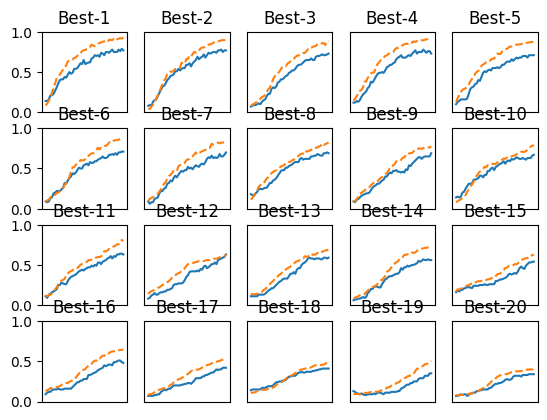

In [17]:
(x_train, t_train), (x_test, t_test) = mnist.load_mnist(normalize=True)

# 결과를 빠르게 얻기 위해 훈련 데이터를 줄임
x_train = x_train[:500]
t_train = t_train[:500]

# 20%를 검증 데이터로 분할
validation_rate = 0.20
validation_num = int(x_train.shape[0] * validation_rate)
x_train, t_train = shuffle_dataset(x_train, t_train)
x_val = x_train[:validation_num]
t_val = t_train[:validation_num]
x_train = x_train[validation_num:]
t_train = t_train[validation_num:]


def __train(lr, weight_decay, epocs=50):
    network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                            output_size=10, weight_decay_lambda=weight_decay)
    trainer = Trainer(network, x_train, t_train, x_val, t_val,
                      epochs=epocs, mini_batch_size=100,
                      optimizer='sgd', optimizer_param={'lr': lr}, verbose=False)
    trainer.train()

    return trainer.test_acc_list, trainer.train_acc_list


# 하이퍼파라미터 무작위 탐색======================================
optimization_trial = 100
results_val = {}
results_train = {}
for _ in range(optimization_trial):
    # 탐색한 하이퍼파라미터의 범위 지정===============
    weight_decay = 10 ** np.random.uniform(-8, -4)
    lr = 10 ** np.random.uniform(-6, -2)
    # ================================================

    val_acc_list, train_acc_list = __train(lr, weight_decay)
    print("val acc:" + str(val_acc_list[-1]) + " | lr:" + str(lr) + ", weight decay:" + str(weight_decay))
    key = "lr:" + str(lr) + ", weight decay:" + str(weight_decay)
    results_val[key] = val_acc_list
    results_train[key] = train_acc_list

# 그래프 그리기========================================================
print("=========== Hyper-Parameter Optimization Result ===========")
graph_draw_num = 20
col_num = 5
row_num = int(np.ceil(graph_draw_num / col_num))
i = 0

for key, val_acc_list in sorted(results_val.items(), key=lambda x:x[1][-1], reverse=True):
    print("Best-" + str(i+1) + "(val acc:" + str(val_acc_list[-1]) + ") | " + key)

    plt.subplot(row_num, col_num, i+1)
    plt.title("Best-" + str(i+1))
    plt.ylim(0.0, 1.0)
    if i % 5: plt.yticks([])
    plt.xticks([])
    x = np.arange(len(val_acc_list))
    plt.plot(x, val_acc_list)
    plt.plot(x, results_train[key], "--")
    i += 1

    if i >= graph_draw_num:
        break

plt.show()